[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/00_Getting_Started_emu.ipynb)

# 00 - Getting Started with the QICK Emulator

**Objective:** Verify your QICK + emulator installation, initialize the emulator in place of a physical RFSoC board, and understand the basic hardware configuration.

This is a 1:1 port of the on-hardware tutorial `00_Getting_Started.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo), running against the Verilator emulator instead of a physical board. Sections and their numbering match the original; only the board-connection and hardware-verification steps are adapted, since the emulator's record-then-replay architecture has no live-register-read equivalent (see Section 4).

```python
soc = QickEmu(str(CFG_PATH))     # instead of QickSoc(BITSTREAM_PATH)
soc = soc.prepare_emu(memdir=OUT)
iq_list = prog.acquire_decimated(soc)   # or prog.acquire(...)
```

Before running this notebook, make sure your environment is set up per [`emulator/README.md`](../../README.md) (Verilator 5.042, git submodules, the `qick-venv` kernel).

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [1]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    else:
        # Update in place instead of just reusing whatever was cloned
        # earlier in this runtime (e.g. from opening a previous notebook in
        # the same session) -- otherwise you silently keep running stale
        # code even though the repo has moved on. This is a bootstrap-only
        # clone, so discarding any local state here is safe.
        print(f"{REPO_DIR} already exists -- updating to the latest {REPO_BRANCH} ...")
        os.chdir(REPO_DIR)
        run(f"git fetch --depth 1 origin {REPO_BRANCH}")
        run("git reset --hard FETCH_HEAD")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    # Needed whether Verilator itself ends up prebuilt or compiled from
    # source: `make verilate` always invokes g++ (via ccache) to compile the
    # *generated* C++ model for each testbench build, every session. Gated
    # on `ccache` specifically (not pre-installed on a bare Colab image, and
    # the exact thing that broke without this) so that re-running this cell
    # -- or moving on to the next notebook in the same runtime -- doesn't
    # re-run apt every single time.
    import shutil
    if shutil.which("ccache") is None:
        print("Installing build/runtime dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )
    else:
        print("Build/runtime dependencies already installed, skipping apt.")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        # Fast path: a prebuilt Verilator 5.042, compiled on a real Colab
        # runtime and hosted as a GitHub Release asset -- avoids a ~10-15
        # minute source compile on every session. Falls back to building
        # from source if the download/extraction doesn't work out (e.g. the
        # asset is gone, or a future Colab image isn't binary-compatible).
        PREBUILT_URL = (
            "https://github.com/openquantumhardware/qick/releases/download/"
            "verilator-5.042-colab/verilator-5.042-colab-x86_64.tar.gz"
        )
        prebuilt_ok = False
        print("Trying prebuilt Verilator 5.042 (fast path) ...")
        try:
            run(f"curl -fL -o /tmp/verilator-prebuilt.tar.gz {PREBUILT_URL}")
            run("tar -C /usr/local -xzf /tmp/verilator-prebuilt.tar.gz")
            prebuilt_ok = "5.042" in verilator_version()
        except RuntimeError as e:
            print(f"Prebuilt Verilator download/install failed ({e}); building from source instead.")

        if prebuilt_ok:
            print("Prebuilt Verilator 5.042 installed.")
        else:
            print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
            os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
            run("autoconf")
            run("./configure")
            run("make -j$(nproc)")
            run("make install")
            os.chdir(REPO_DIR)
            final_version = verilator_version()
            if "5.042" not in final_version:
                raise RuntimeError(
                    "Verilator build finished but 'verilator --version' still doesn't "
                    f"report 5.042 (got: {final_version!r})"
                )
            print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


Not running in Colab -- skipping clone/build (using the local checkout as-is).


## 1. Setup and Imports

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

# Core QICK imports
import qick
from qick import *

# tProc v2 specific classes
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan

# Emulator entry point (drop-in replacement for QickSoc)
from qick_emu import QickEmu

# Optional: increase logging level for debugging
# logging.basicConfig(level=logging.DEBUG)
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
# Reduce noise from the tProc core
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Display the loaded QICK library version
print(f"QICK Version: {qick.get_version()}")

QICK Version: 0.2.88


**Explanation:** Same imports as the on-hardware notebook, plus `QickEmu` from `emulator/software/qick_emu.py` — the emulator's drop-in replacement for `QickSoc`. The `qick.asm_v2` module contains the classes for building tProc v2 programs; that part of your code doesn't change between hardware and emulator.

## 2. Initialize the QICK Emulator

On real hardware you'd point `QickSoc` at a firmware `.bit` file specific to your board. The emulator instead loads a board config JSON that describes the same firmware (channels, clocks, tProc) as a Verilator simulation — no board, no bitstream file, no Xilinx tools required.

In [3]:
# --- No firmware .bit file or physical board needed ---
# On real hardware you'd do:
#     BITSTREAM_PATH = '/path/to/your/firmware.bit'
#     soc = QickSoc(BITSTREAM_PATH)
#
# The emulator loads the same kind of information from a JSON config instead,
# and hands back a `soc`-compatible object with the same API used below.
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'

soc    = QickEmu(str(CFG_PATH))
soccfg = soc.soccfg  # 'soccfg' is a common alias used throughout QICK examples

# Where this notebook's simulation artifacts (CSVs, .mem files) get written
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_getting_started'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

print("\n=== Emulator Initialized ===")

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.



=== Emulator Initialized ===


## 3. Inspect the Hardware Configuration

The `soccfg` object is a `QickConfig` — the exact same class used on real hardware — so it contains the same information about the (simulated) firmware: clock frequencies, generator channels, readout channels, digital I/O, and tProc capabilities.

In [4]:
print(soccfg)

QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Fri Sep 4 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	3 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is QICKEmu DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is QICKEmu DAC port 1
	2:	axis_sg_mux8_v1 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is QICKEmu DAC port 2

	6 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 4
		fs=2457.600 Msps, decimated=307.200 MHz

**Explanation:** The printed output shows:
- **Global clocks:** tProc timing clock, RF reference frequency
- **Signal generators:** Number of channels, sample rates, envelope memory size
- **Readout channels:** Sample rates, buffer sizes, trigger mappings
- **tProc configuration:** Program memory size, data memory size, waveform memory size, core clock

This is the same information — and the same object type — you'd inspect on real hardware. `qick_emu_config.json` does not model DDR4 buffers (the emulator testbench doesn't instantiate that IP), so you won't see a `DDR4 memory buffer` line here even if the board config it's based on has one.

## 4. Quick Emulator Test

On hardware, `get_tproc_counter()` and `read_mem()` read live registers over the PYNQ/AXI interface to confirm the board is responding. The emulator has no live board to poll: it works by **recording** the AXI writes your program issues and then **replaying** them in a single batched Verilator simulation, so there's nothing to read back until a simulation has actually run (`soc.reg_read()` is a documented no-op for exactly this reason).

The emulator-equivalent smoke test is to run one minimal program through the full pipeline — Python → AXI record → Verilator → CSV — and confirm real data comes back. That's what actually proves your toolchain (Verilator 5.042, the git submodules, the `qick-venv` environment) is working end-to-end.

Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/00_getting_started/smoke_test
[verilate] Building QICKEmu_harness ...
verilator --binary --exe --build -j 0 -Wall  --Wno-fatal --error-limit 1 --timing -Wno-DECLFILENAME -Wno-PINCONNECTEMPTY -Wno-VARHIDDEN -Wno-TIMESCALEMOD -Wno-EOFNEWLINE -Wno-WIDTH -Wno-PINMISSING -Wno-BADVLTPRAGMA -Wno-CONSTRAINTIGN -I../../emulator/submodules/pulp_platform/axi/include -I../../emulator/submodules/pulp_platform/common_verification/include -I../../emulator/submodules/pulp_platform/common_cells/include -I../../firmware/ip/qick_processor/src -y ../../emulator/models/bram_dp -y ../../emulator/models/fifo -y ../../emulator/models/dac_model -y ../../emulator/models/dds_model -y ../../emulator/models/dds_model/src -y ../../firmware/ip/common -y ../../firmware/ip/qick_common verilator.vlt --top-module QICKEmu_harness -work lib_axis_pfb_readout_v3 ../../firmware/ip/axis_pfb_readout_v3/src/axis_pfb_readout_v3.v ../../firmware/ip/axis_pfb_readout_v3/

1265100.000 - Load SGs Envelope Table Memories
### 1265100.000 - Task sg_load_mem() start ###
   ### 1265100.000 - SG ch0: no envelope file /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/00_getting_started/smoke_test/sgmem_ch0.mem ###
   ### 1265100.000 - SG ch1: no envelope file /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/00_getting_started/smoke_test/sgmem_ch1.mem ###
### 1265100.000 - Task sg_load_mem() end ###
2265100.000 - Applying pre-run startup delay of 85 ns
2350100.000 - Replaying AXI Writes from axi_replay.txt
### 2350100.000 - Task replay_axi_writes() start ###
   ### replay line #0 parsed: addr=0x4001c0010 data=0x00000001 ###
### 2355100.000 - Routing AXI write: addr=0x4001c0010 data=0x00000001 ###
   ### replay line #1 parsed: addr=0x400060000 data=0x00000000 ###
### 2515100.000 - Routing AXI write: addr=0x400060000 data=0x00000000 ###
   ### replay line #2 parsed: addr=0x400060004 data=0x00000000 ###
### 2675100.000 - Routing AXI write: addr=0x400060004 data=0x000

### 3475100.000 - Routing AXI write: addr=0x400060000 data=0x00000001 ###
   ### replay line #8 parsed: addr=0x400060018 data=0x00000001 ###
### 3635100.000 - Routing AXI write: addr=0x400060018 data=0x00000001 ###
   ### replay line #9 parsed: addr=0x400260000 data=0x00000004 ###
### 3795100.000 - Routing AXI write: addr=0x400260000 data=0x00000004 ###
### 3945000.000 - AXI replay done: 10 transactions replayed ###
3945000.000 - Start tProc execution
4945000.000 - End tProc execution
4945000.000 - Read Average and Decimation Buffers
### 4945000.000 - Task read_avg_dec_buffers() channel 0 start ###


### 6305000.000 - Task read_avg_dec_buffers() channel 0 end ###
### 6305000.000 - Task read_avg_dec_buffers() channel 1 start ###
### 7665000.000 - Task read_avg_dec_buffers() channel 1 end ###
### 7665000.000 - Task read_avg_dec_buffers() channel 2 start ###


### 9025000.000 - Task read_avg_dec_buffers() channel 2 end ###
### 9025000.000 - Task read_avg_dec_buffers() channel 3 start ###
### 10385000.000 - Task read_avg_dec_buffers() channel 3 end ###


60385000.000 - Closing CSV files
60385000.000 - End Emulation
- ../../emulator/testbench/QICKEmu_harness.sv:1201: Verilog $finish
- S i m u l a t i o n   R e p o r t: Verilator 5.042 2025-11-02
- Verilator: $finish at 60us; walltime 4.532 s; speed 13.321 us/s
- Verilator: cpu 4.533 s on 1 threads; alloced 257 MB
[ok] CSV outputs: dac0=dac_out_ch0.csv, dac1=dac_out_ch1.csv, dac2=dac_out_ch2.csv, avg0=avg_out_ch0.csv, dec0=dec_out_ch0.csv, avg1=avg_out_ch1.csv, dec1=dec_out_ch1.csv, avg2=avg_out_ch2.csv, dec2=dec_out_ch2.csv, mr=mr_out.csv

✓ Emulator pipeline verified: acquired 92 decimated I/Q samples.


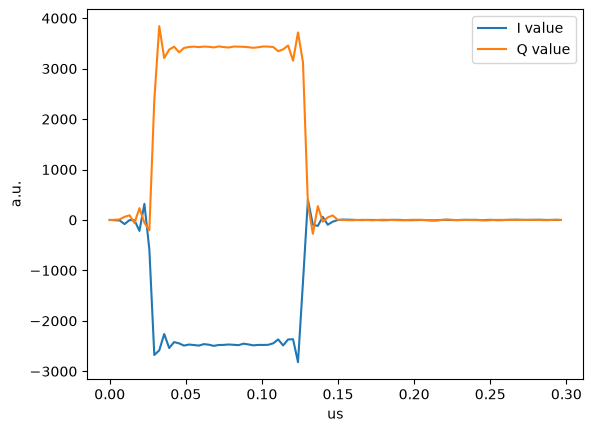

In [5]:
class SmokeTestProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const', length=0.1,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)


config = {
    'gen_ch':    0,     # QICKEmu channel assignment, see 00_intro_emu.ipynb
    'ro_ch':     0,
    'freq':      100,   # MHz
    'trig_time': 0.40,  # us
    'ro_len':    0.3,   # us
}

prog = SmokeTestProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'smoke_test'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {OUT}')

# First simulation of the kernel session: build=True runs `make verilate`,
# a full compile of the Verilator testbench (the slow step, ~1-2 min).
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used on later runs.
soc = soc.prepare_emu(memdir=OUT, build=True, verbose=True)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

print(f"\n✓ Emulator pipeline verified: acquired {iq_list[0].shape[0]} decimated I/Q samples.")

plt.plot(t, iq_list[0][:, 0], label="I value")
plt.plot(t, iq_list[0][:, 1], label="Q value")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

**Explanation:** `prepare_emu()` resets the emulator's recorder and points it at a fresh artifacts directory; `acquire_decimated()` then records the program's AXI transactions, invokes `make verilate` + the compiled testbench binary, and parses the resulting `dec_out_ch0.csv` back into the `iq_list` array you'd get on real hardware. Getting a nonzero-length I/Q array back — and a pulse-shaped plot above — confirms the whole chain works.

## 5. Summary

You are now ready to start writing QICK experiments against the emulator. [`00_intro_emu.ipynb`](../00_intro_emu.ipynb) picks up from here with a full set of pulse-sequencing and acquisition examples (the emulator port of the original `00_intro.ipynb`).

**Key takeaways:**
- Use `QickEmu(cfg_path)` instead of `QickSoc(bitfile_path)` — no board or bitstream needed
- The `soccfg` object holds the same hardware configuration information as on real hardware
- `prog.acquire()` / `prog.acquire_decimated()` transparently dispatch to the emulator when `soc` is a `QickEmu`
- The emulator has no live register reads (`reg_read()` is a no-op); to verify the toolchain, run a minimal program end-to-end instead
- `build=True` (compiling the Verilator testbench) only needs to happen once per kernel session — see the performance note in `00_intro_emu.ipynb`